<a href="https://colab.research.google.com/github/NoeliaFerrero/Comi-96160-Data-Science-II-Machine-Learning-para-la-Ciencia-de-Datos-Diplomaturas/blob/main/Semana%2012%20Clasificacion%20y%20Regresion/Sem12_Clasificacion_y_Regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 De clasificar a predecir

## Algoritmos de clasificación y regresión

En este notebook vamos a llevar a la práctica algunos conceptos de la clase:

- Clasificación
- SVM
- Regresión lineal
- Train / Test
- Predicciones
- Evaluación de modelos
- Hiperparámetros

La pregunta que vamos a responder es:

> **¿Qué cambia cuando queremos predecir una categoría y qué cambia cuando queremos predecir un número?**


## 🎯 Dos problemas, dos tipos de Machine Learning

Vamos a trabajar con datos de clientes.

Primero queremos saber:

> **¿El cliente va a comprar?**

👉 Problema de **clasificación**

Después queremos saber:

> **¿Cuánto dinero va a gastar?**

👉 Problema de **regresión**

La diferencia fundamental está en nuestra variable objetivo:

- **Clasificación → categorías**
- **Regresión → valores numéricos**


In [ ]:
# Importamos las herramientas que vamos a utilizar

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score


## 👀 Creamos un pequeño dataset

Para concentrarnos en Machine Learning y no perder tiempo limpiando un dataset real, vamos a trabajar con datos sencillos de clientes.

Cada fila representa un cliente.


In [ ]:
datos = pd.DataFrame({
    "edad": [22, 25, 28, 31, 35, 38, 42, 45, 48, 52, 55, 58,
             23, 27, 30, 34, 40, 44, 50, 53],

    "visitas_web": [2, 3, 4, 5, 5, 6, 7, 8, 9, 9, 10, 11,
                    2, 4, 5, 6, 7, 8, 9, 10],

    "compras_previas": [0, 0, 1, 1, 2, 2, 3, 4, 4, 5, 6, 7,
                        0, 1, 1, 2, 3, 3, 5, 6],

    "compro": [0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
               0, 0, 1, 1, 1, 1, 1, 1]
})

datos.head()


,edad,visitas_web,compras_previas,compro
0,22,2,0,0
1,25,3,0,0
2,28,4,1,0
3,31,5,1,1
4,35,5,2,1


In [ ]:
# ¿Qué información tenemos?

datos.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   edad             20 non-null     int64
 1   visitas_web      20 non-null     int64
 2   compras_previas  20 non-null     int64
 3   compro           20 non-null     int64
dtypes: int64(4)
memory usage: 772.0 bytes


In [ ]:
# Algunas estadísticas descriptivas

datos.describe()


,edad,visitas_web,compras_previas,compro
count,20.000000,20.000000,20.000000,20.000000
mean,39.000000,6.500000,2.800000,0.750000
std,11.350864,2.724161,2.166734,0.444262
min,22.000000,2.000000,0.000000,0.000000
25%,29.500000,4.750000,1.000000,0.750000
50%,39.000000,6.500000,2.500000,1.000000
75%,48.500000,9.000000,4.250000,1.000000
max,58.000000,11.000000,7.000000,1.000000


## 📊 Visualizamos los datos

Cada punto representa un cliente.

El color representa nuestra variable objetivo:

- `0` → No compra
- `1` → Compra


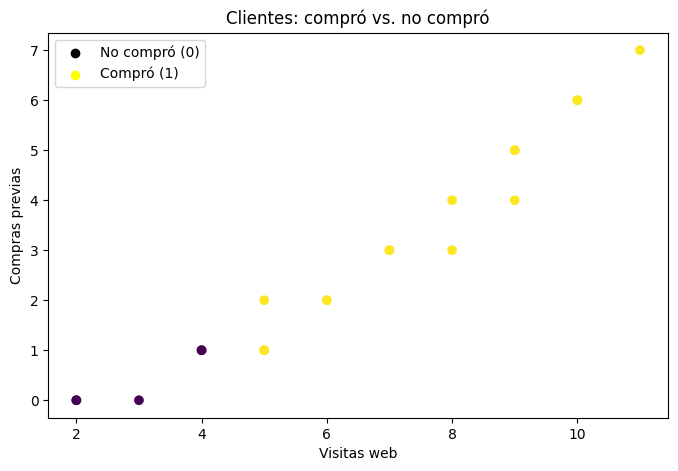

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    datos["visitas_web"],
    datos["compras_previas"],
    c=datos["compro"]
)

plt.xlabel("Visitas web")
plt.ylabel("Compras previas")
plt.title("Clientes: compró vs. no compró")

# Leyenda
plt.scatter([], [], c="black", label="No compró (0)")
plt.scatter([], [], c="yellow", label="Compró (1)")
plt.legend()

plt.show()

# 🟣 PARTE 1 — CLASIFICACIÓN

## Pregunta

> **¿Este cliente va a comprar?**

Nuestra variable objetivo es:

`compro`

- `0` → No compra
- `1` → Compra

Por lo tanto:

### Tenemos un problema de clasificación.


## 🧩 Separamos X e Y

- **X** → información que utilizamos para aprender
- **y** → variable que queremos predecir


In [ ]:
X = datos[["edad", "visitas_web", "compras_previas"]]
y = datos["compro"]

print("Variables X:")
display(X.head())

print("Variable objetivo y:")
display(y.head())


Variables X:


,edad,visitas_web,compras_previas
0,22,2,0
1,25,3,0
2,28,4,1
3,31,5,1
4,35,5,2


Variable objetivo y:


,compro
0,0
1,0
2,0
3,1
4,1


## ✂️ Train / Test

No queremos entrenar y evaluar al modelo exactamente con los mismos datos.

Por eso dividimos nuestro dataset:

- **Train** → datos que utilizamos para entrenar
- **Test** → datos que dejamos aparte para evaluar


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", len(X_train))
print("Datos de prueba:", len(X_test))


Datos de entrenamiento: 15
Datos de prueba: 5


## 🤖 Entrenamos un SVM

SVM busca una frontera que permita separar las clases.

En este ejemplo utilizaremos un kernel lineal para mantener la explicación sencilla.


In [ ]:
modelo_svm = SVC(kernel="linear")

modelo_svm.fit(X_train, y_train)


SVC(kernel='linear')

## 🔮 Hacemos predicciones

Ahora el modelo recibe datos que no utilizó para entrenarse y realiza sus predicciones.

Vamos a comparar:

- lo que realmente ocurrió
- lo que predijo el modelo


In [ ]:
y_pred = modelo_svm.predict(X_test)

comparacion_clasificacion = pd.DataFrame({
    "Real": y_test.values,
    "Predicción": y_pred
})

comparacion_clasificacion


,Real,Predicción
0,0,0
1,1,1
2,1,1
3,1,1
4,1,1


## 📏 Evaluamos el modelo

Una métrica sencilla para empezar es **Accuracy**.

Nos indica qué proporción de las predicciones fueron correctas.


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")


Accuracy: 100.00%


### 🧠 Para pensar

Si el modelo obtuvo 80% de accuracy...

**¿significa automáticamente que es un buen modelo?**

No necesariamente.

También necesitamos preguntarnos:

- ¿Qué problema estamos resolviendo?
- ¿Qué errores está cometiendo?
- ¿Qué costo tiene cada error?
- ¿Cómo se comporta con datos nuevos?


# ⚙️ Hiperparámetros

Los hiperparámetros son configuraciones que nosotros definimos para el modelo.

En SVM, por ejemplo, `C` es uno de los hiperparámetros.

Vamos a probar distintas configuraciones.


In [ ]:
modelo_svm_2 = SVC(
    kernel="linear",
    C=0.1
)

modelo_svm_2.fit(X_train, y_train)

y_pred_2 = modelo_svm_2.predict(X_test)

accuracy_2 = accuracy_score(y_test, y_pred_2)

print(f"Accuracy con C=0.1: {accuracy_2:.2%}")


Accuracy con C=0.1: 100.00%


In [ ]:
# Probamos diferentes valores de C

for c in [0.01, 0.1, 1, 10, 100]:

    modelo = SVC(
        kernel="linear",
        C=c
    )

    modelo.fit(X_train, y_train)

    predicciones = modelo.predict(X_test)

    accuracy = accuracy_score(y_test, predicciones)

    print(f"C = {c:<5} → Accuracy = {accuracy:.2%}")


C = 0.01  → Accuracy = 100.00%
C = 0.1   → Accuracy = 100.00%
C = 1     → Accuracy = 100.00%
C = 10    → Accuracy = 100.00%
C = 100   → Accuracy = 100.00%


### 💡 ¿Qué acabamos de hacer?

Probamos diferentes valores de un hiperparámetro.

Esto es una versión sencilla de **hyperparameter tuning**.

La idea general es:

> **Probar configuraciones y comparar su desempeño.**

⚠️ En un proyecto real, la búsqueda de hiperparámetros debe hacerse utilizando una estrategia de validación adecuada y sin utilizar el conjunto de test para "tunear" el modelo.


# 🔵 PARTE 2 — REGRESIÓN

Ahora cambiamos la pregunta.

Ya no queremos saber:

> **¿Compra o no compra?**

Ahora queremos saber:

> **¿Cuánto dinero va a gastar?**

La variable objetivo ahora será numérica.

Por lo tanto:

### Tenemos un problema de regresión.


## 💰 Creamos nuestra variable objetivo

Vamos a agregar una variable `gasto` que representa el gasto del cliente.

En un problema real, esta variable vendría de nuestros datos históricos.


In [ ]:
datos["gasto"] = (
    1000
    + datos["edad"] * 150
    + datos["visitas_web"] * 500
    + datos["compras_previas"] * 1200
)

datos.head()


,edad,visitas_web,compras_previas,compro,gasto
0,22,2,0,0,5300
1,25,3,0,0,6250
2,28,4,1,0,8400
3,31,5,1,1,9350
4,35,5,2,1,11150


## 📊 Visualizamos la relación

Ahora ya no estamos intentando separar dos categorías.

Queremos observar cómo se relacionan nuestras variables con un valor numérico: el gasto.


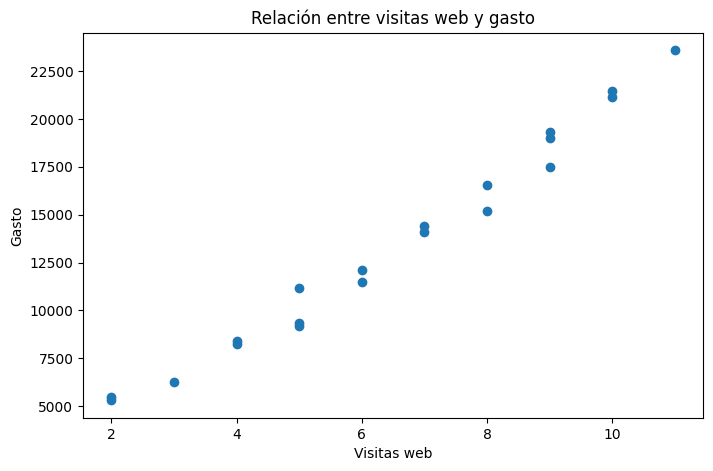

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    datos["visitas_web"],
    datos["gasto"]
)

plt.xlabel("Visitas web")
plt.ylabel("Gasto")
plt.title("Relación entre visitas web y gasto")

plt.show()


## 🧩 Nuevamente separamos X e Y

Esta vez:

- **X** → variables que utilizamos para predecir
- **y** → gasto que queremos predecir


In [ ]:
X = datos[["edad", "visitas_web", "compras_previas"]]
y = datos["gasto"]


## ✂️ Train / Test

El flujo general sigue siendo muy parecido:

```text
Datos
   ↓
X / y
   ↓
Train / Test
   ↓
Modelo
   ↓
Predicción
   ↓
Evaluación
```

Lo que cambia es el **tipo de problema** y el **modelo** que utilizamos.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)


## 📈 Entrenamos una Regresión Lineal

La regresión lineal busca modelar una relación entre nuestras variables de entrada y una variable objetivo numérica.


In [ ]:
modelo_regresion = LinearRegression()

modelo_regresion.fit(X_train, y_train)


LinearRegression()

## 🔎 Miramos los coeficientes

Recordemos la idea de la regresión lineal múltiple:

**Y = α + β₁X₁ + β₂X₂ + ... + βₙXₙ + ε**

Cada coeficiente `β` está asociado a una de nuestras variables.


In [ ]:
print("Intercepto:", modelo_regresion.intercept_)

for variable, coeficiente in zip(X.columns, modelo_regresion.coef_):
    print(f"{variable} → {coeficiente:.2f}")


Intercepto: 999.9999999999964
edad → 150.00
visitas_web → 500.00
compras_previas → 1200.00


## 🔮 Predecimos

Ahora usamos el modelo entrenado para estimar el gasto de los clientes del conjunto de prueba.


In [ ]:
y_pred = modelo_regresion.predict(X_test)

comparacion_regresion = pd.DataFrame({
    "Real": y_test.values,
    "Predicción": y_pred.round(2)
})

comparacion_regresion


,Real,Predicción
0,5300,5300.0
1,15200,15200.0
2,11500,11500.0
3,6250,6250.0
4,17500,17500.0


## 📏 Evaluamos: MAE

**MAE = Mean Absolute Error**

Nos indica, en promedio, cuánto se alejan nuestras predicciones del valor real, en términos absolutos.

Por ejemplo:

> Si MAE = $2.000,  nuestras  predicciones se alejan en promedio unos $2.000 del valor real.


In [ ]:
mae = mean_absolute_error(y_test, y_pred)

print(f"MAE: ${mae:,.0f}")


MAE: $0


## 📐 Evaluamos: R²

R² nos permite analizar qué proporción de la variabilidad de la variable objetivo puede explicar el modelo.

Por ejemplo:

> R² = 0.80 → el modelo explica aproximadamente el 80% de la variabilidad de Y dentro de este conjunto de datos.


In [ ]:
r2 = r2_score(y_test, y_pred)

print(f"R²: {r2:.2f}")


R²: 1.00


# 🧩 CLASIFICACIÓN vs. REGRESIÓN

| Problema | Variable objetivo | Modelo utilizado |
|---|---|---|
| ¿Compra? | Categoría | SVM |
| ¿Cuánto gasta? | Número | Regresión Lineal |

## La idea central

**No empezamos por el algoritmo.**

Primero definimos:

1. ¿Qué queremos predecir?
2. ¿Qué tipo de variable es?
3. ¿Qué datos tenemos?
4. ¿Qué modelo puede ayudarnos?
5. ¿Cómo vamos a evaluar el resultado?


# 🎯 MINI DESAFÍO

Pensá en cada situación.

### Caso 1
Una empresa quiere saber si un cliente va a cancelar su suscripción.

👉 ¿Clasificación o regresión?

### Caso 2
Una inmobiliaria quiere estimar el precio de una vivienda.

👉 ¿Clasificación o regresión?

### Caso 3
Un banco quiere estimar cuánto dinero gastará un cliente durante el próximo mes.

👉 ¿Clasificación o regresión?

### Caso 4
Queremos probar distintos valores de un hiperparámetro para mejorar el modelo.

👉 ¿Qué estamos haciendo?


# ✅ SOLUCIONES

### Caso 1 → Clasificación

Queremos obtener una categoría:

- Cancela
- No cancela

### Caso 2 → Regresión

Queremos obtener un número:

- $80.000
- $120.000
- $250.000
- etc.

### Caso 3 → Regresión

Queremos predecir un valor numérico.

### Caso 4 → Optimización de hiperparámetros

Estamos probando diferentes configuraciones del modelo.


# 🧠 PARA LLEVARSE HOY

### Clasificación
Predice **categorías**.

### Regresión
Predice **valores numéricos**.

### SVM
Busca una buena frontera de separación entre clases.

### Regresión Lineal
Busca modelar relaciones lineales entre variables.

### Parámetros
Los aprende el modelo.

### Hiperparámetros
Los configuramos nosotros.

---

## ⭐ Y lo más importante

> **Primero definimos el problema.**
>
> **Después elegimos el modelo.**
